<div align="center">

# Assignment 2

</div>

# 🎯 Objective

The goal of this assignment is to:

* implement **multivariate linear regression** in PyTorch using only tensors,
* use **autograd** to compute gradients,
* implement **gradient descent updates manually** (no `torch.optim`),
* understand the role of **feature scaling** and **learning rate**,
* compare gradient descent with the **closed-form (normal equation)** solution.

This assignment focuses on **training mechanics and optimization**, not neural network architectures yet.


---

## 📌 General Requirements

* Use **PyTorch**
* Submit a **Jupyter Notebook (.ipynb)**
* Notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names.
* Code must be reproducible (no hidden state, no manual cell skipping).


---

# ⚠ Restrictions (Important)

For the entire assignment:

✅ Allowed:

* `torch.Tensor` operations
* `loss.backward()`

❌ Not allowed:

* `torch.optim.*`
* `torch.nn.Linear` (and generally `torch.nn` layers)
* high-level loss modules (`nn.MSELoss`, etc.) — compute MSE manually
* high-level training wrappers (Lightning, fastai, Trainer APIs)


---

# Task 1 — Multivariate Linear Regression + Manual Training Loop (3 pts)

We consider the model:

$$
\hat y = XW+b
$$


Where:

* $ X \in \mathbb R^{N×d} $ 


* $W \in \mathbb R^{d×1}$
* $b \in \mathbb R$

### Requirements


1. Prepare a dataset with **at least 300 samples** and **at least 3 features**:
   * Option A: use a real dataset (recommended), e.g. **[California Housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)** (you may use `sklearn.datasets.fetch_california_housing()` only for loading data, not modeling),
   * Option B: generate synthetic data with d ≥ 3.
2. Split data into **train / validation** (e.g., 80% / 20%).
3. Normalize features using statistics from the training set:

$$
X' = \frac{X-\mu}{\sigma}
$$


4. Initialize parameters:

* `W ~ N(0,1)` (shape `d x 1`)
* `b ~ N(0,1)` (scalar)

  with `requires_grad=True`.


5. Implement:

* forward pass,
* **MSE loss manually**:

$$
MSE = \frac{1}{N} \sum_{i=1}^{N} \left(\hat y_i-y_i\right)^2
$$

* training loop for 200–1000 epochs,
* manual gradient descent update using `torch.no_grad()`:
  * update `W`, `b`,
  * then reset gradients correctly.


6. Plot:

* training loss vs epoch,
* validation loss vs epoch.

### Required Explanation (Markdown)

* Why do we need `torch.no_grad()` during parameter update?
* Why must we reset gradients each iteration?
* Why does feature normalization typically help optimization?


---

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

SEED = 42

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load dataset (only for data loading — no sklearn modeling used)
housing = fetch_california_housing()

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=SEED
)

print(f"Training samples  : {X_train_np.shape[0]}")
print(f"Validation samples: {X_val_np.shape[0]}")
print(f"Number of features: {X_train_np.shape[1]}")
print(f"Feature names     : {housing.feature_names}")


Training samples  : 16512
Validation samples: 4128
Number of features: 8
Feature names     : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [2]:
# Normalize using statistics computed ONLY on the training set
X_mean = X_train_np.mean(axis=0)   # (d,)
X_std  = X_train_np.std(axis=0)    # (d,)

X_train_norm = (X_train_np - X_mean) / X_std
X_val_norm   = (X_val_np   - X_mean) / X_std   # use train stats — no leakage

# Convert to float32 tensors
X_train = torch.tensor(X_train_norm, dtype=torch.float32)
X_val   = torch.tensor(X_val_norm,   dtype=torch.float32)
y_train = torch.tensor(y_train_np,   dtype=torch.float32).unsqueeze(1)  # (N, 1)
y_val   = torch.tensor(y_val_np,     dtype=torch.float32).unsqueeze(1)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}  |  y_val: {y_val.shape}")
print(f"Feature means after normalization (≈ 0): {X_train.mean(dim=0).numpy().round(3)}")
print(f"Feature stds  after normalization (≈ 1): {X_train.std(dim=0).numpy().round(3)}")


X_train: torch.Size([16512, 8])  |  X_val: torch.Size([4128, 8])
y_train: torch.Size([16512, 1])  |  y_val: torch.Size([4128, 1])
Feature means after normalization (≈ 0): [-0.  0. -0.  0. -0. -0.  0.  0.]
Feature stds  after normalization (≈ 1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [3]:
# --- Parameters ---
d = X_train.shape[1]
torch.manual_seed(SEED)
W = torch.randn(d, 1, requires_grad=True)   # (d, 1)
b = torch.randn(1,    requires_grad=True)   # scalar

learning_rate = 0.05
n_epochs      = 800

# --- Training loop ---
train_losses = []
val_losses   = []

for epoch in range(n_epochs):
    # Forward pass
    y_pred_train = X_train @ W + b                            # (N, 1)

    # MSE loss (manual)
    loss_train = ((y_pred_train - y_train) ** 2).mean()

    # Backward pass (autograd computes gradients)
    loss_train.backward()

    # Manual gradient descent update — must NOT be tracked by autograd
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad
        # Reset gradients for next iteration
        W.grad.zero_()
        b.grad.zero_()

    # Validation loss (no gradients needed)
    with torch.no_grad():
        y_pred_val = X_val @ W + b
        loss_val   = ((y_pred_val - y_val) ** 2).mean()

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:4d} | Train MSE: {loss_train.item():.4f} | Val MSE: {loss_val.item():.4f}")

print(f"\nFinal Train MSE : {train_losses[-1]:.4f}")
print(f"Final Val   MSE : {val_losses[-1]:.4f}")


Epoch   10 | Train MSE: 1.6053 | Val MSE: 1.4438
Epoch   20 | Train MSE: 0.8914 | Val MSE: 0.8810
Epoch   30 | Train MSE: 0.7779 | Val MSE: 0.7811
Epoch   40 | Train MSE: 0.7327 | Val MSE: 0.7389
Epoch   50 | Train MSE: 0.7023 | Val MSE: 0.7104
Epoch   60 | Train MSE: 0.6777 | Val MSE: 0.6878
Epoch   70 | Train MSE: 0.6569 | Val MSE: 0.6689
Epoch   80 | Train MSE: 0.6390 | Val MSE: 0.6531
Epoch   90 | Train MSE: 0.6236 | Val MSE: 0.6396
Epoch  100 | Train MSE: 0.6103 | Val MSE: 0.6282
Epoch  110 | Train MSE: 0.5987 | Val MSE: 0.6185
Epoch  120 | Train MSE: 0.5887 | Val MSE: 0.6103
Epoch  130 | Train MSE: 0.5800 | Val MSE: 0.6033
Epoch  140 | Train MSE: 0.5724 | Val MSE: 0.5973
Epoch  150 | Train MSE: 0.5658 | Val MSE: 0.5922
Epoch  160 | Train MSE: 0.5601 | Val MSE: 0.5879
Epoch  170 | Train MSE: 0.5551 | Val MSE: 0.5842
Epoch  180 | Train MSE: 0.5507 | Val MSE: 0.5810
Epoch  190 | Train MSE: 0.5469 | Val MSE: 0.5783
Epoch  200 | Train MSE: 0.5436 | Val MSE: 0.5760
Epoch  210 | Train M

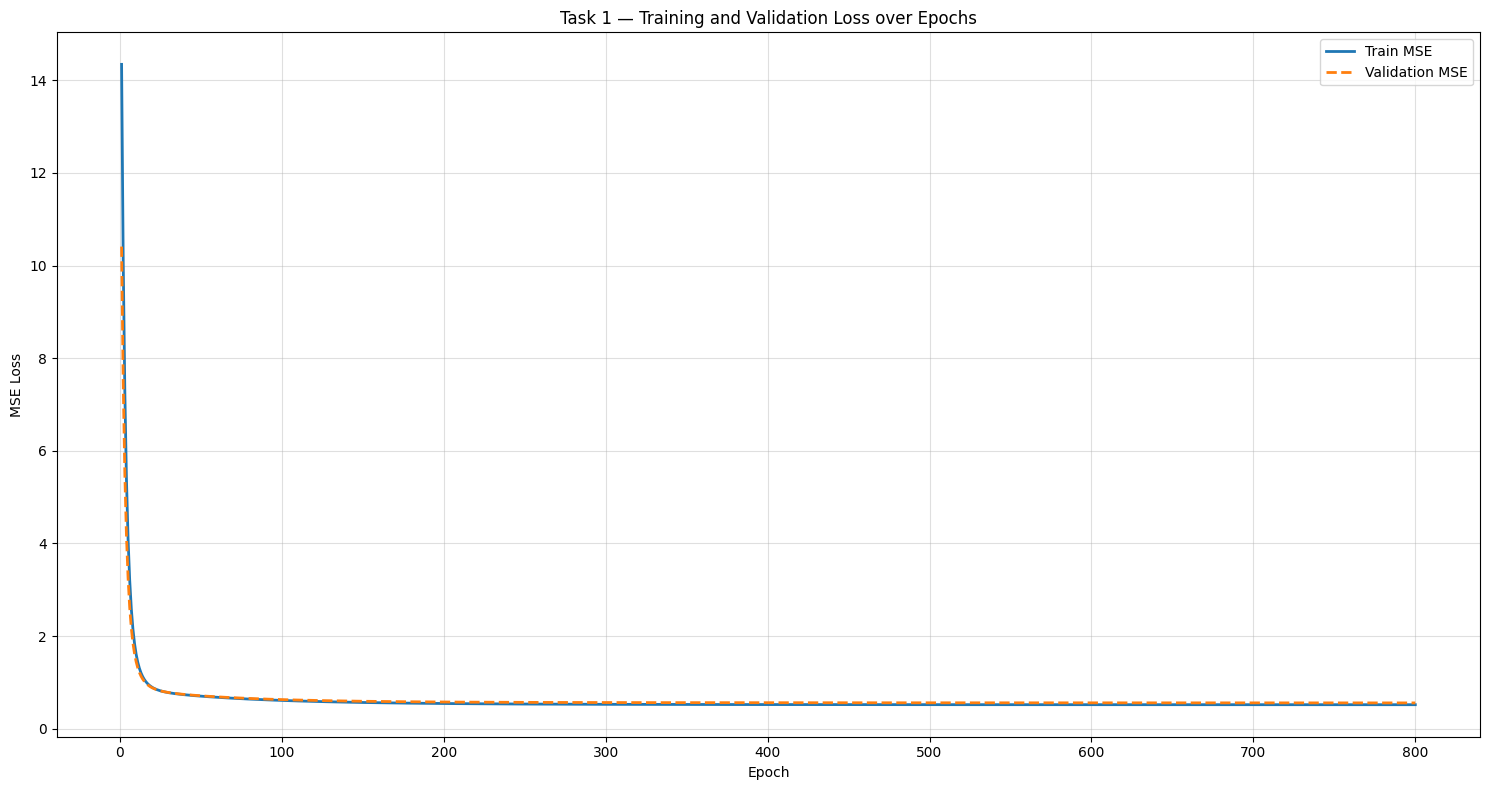

In [4]:
plt.figure(figsize=(15, 8))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train MSE', linewidth=2)
plt.plot(range(1, n_epochs + 1), val_losses,   label='Validation MSE', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Task 1 — Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### Task 1 — Explanations

**Why do we need `torch.no_grad()` during parameter update?**

When we execute the manual gradient descent step (`W -= lr * W.grad`), we do *not* want PyTorch to record this operation in the autograd computation graph. Without `torch.no_grad()`, PyTorch would track the parameter update itself as a differentiable operation, which would corrupt the graph for future `.backward()` calls and waste memory. The update is a procedural, non-differentiable step — it should be invisible to autograd.

---

**Why must we reset gradients each iteration?**

PyTorch **accumulates** gradients by default: every call to `.backward()` **adds** newly computed gradients on top of whatever is already stored in `.grad`. If we never zero the gradients, the stored value grows as the sum of all past gradients, and the update applied to `W` and `b` would be orders of magnitude too large. Calling `.grad.zero_()` after each update ensures that each epoch's step is driven only by the current epoch's gradient.

---

**Why does feature normalization typically help optimization?**

Without normalization, features can span very different scales (e.g., `MedInc` ≈ 0–15, `Population` ≈ 0–36 000). This creates a loss surface with highly elongated elliptical contours: the gradient direction is dominated by large-scale features, and a single learning rate must simultaneously be small enough not to overshoot in steep directions and large enough to make progress in flat ones. After z-score normalization (zero mean, unit variance) the loss contours become much more isotropic — the Hessian has more balanced eigenvalues — so a single moderate learning rate works well across all dimensions, enabling faster and more stable convergence.




# Task 2 — Closed-Form Solution (Normal Equation) (2 pts)

⚠ **This task is a direct continuation of Task 1.**

You must use:

* The **same dataset**
* The **same train/validation split**
* The **same feature normalization**
* The **same training set** for computing parameters

In Task 1, you trained the model using **gradient descent**.

In this task, you will compute the **analytical solution** for linear regression and compare it to the gradient descent solution.


Recall that for linear regression with MSE loss, the optimal parameters can be obtained by solving:

$$
W^* = (X^TX)^{-1} X^T y
$$

You may use:

* `torch.linalg.solve` or `torch.linalg.pinv`

It is recommended to include the bias term by augmenting the input matrix with a column of ones.

### Requirements


1. Compute *W\** (and *b* if you separate it).
2. Compute training and validation MSE for:
   * Gradient Descent solution
   * Closed-form solution
3. Compare the results.

### Required Explanation (Markdown)

* When is the closed-form solution feasible, and when is it not?
* Why might gradient descent not match the closed-form result exactly (even on convex problems)?

---


In [5]:
# Task 2 — Closed-Form Solution (Normal Equation)
# Augment X with a column of ones to absorb the bias term into W
ones_train = torch.ones(X_train.shape[0], 1)
ones_val   = torch.ones(X_val.shape[0],   1)

X_train_aug = torch.cat([X_train, ones_train], dim=1)   # (N_train, d+1)
X_val_aug   = torch.cat([X_val,   ones_val],   dim=1)   # (N_val,   d+1)

# Solve (X^T X) W* = X^T y  →  avoids explicit inversion (more numerically stable)
A      = X_train_aug.T @ X_train_aug    # (d+1, d+1)
b_rhs  = X_train_aug.T @ y_train        # (d+1, 1)
W_star = torch.linalg.solve(A, b_rhs)  # (d+1, 1)

W_cf      = W_star[:-1]          # feature weights  (d, 1)
b_cf_bias = W_star[-1]           # bias scalar

print(f"Closed-form W shape : {W_cf.shape}")
print(f"Closed-form bias    : {b_cf_bias.item():.4f}")
print(f"GD bias             : {b.item():.4f}")
print(f"\nWeight comparison (GD vs CF):")
print(f"  {'Feature':<14}  {'W_gd':>10}  {'W_cf':>10}")
print("-" * 38)
for name, wg, wc in zip(housing.feature_names, W.detach().numpy().flatten(), W_cf.numpy().flatten()):
    print(f"  {name:<14}  {wg:>10.4f}  {wc:>10.4f}")


Closed-form W shape : torch.Size([8, 1])
Closed-form bias    : 2.0719
GD bias             : 2.0719

Weight comparison (GD vs CF):
  Feature               W_gd        W_cf
--------------------------------------
  MedInc              0.8621      0.8544
  HouseAge            0.1244      0.1225
  AveRooms           -0.3078     -0.2944
  AveBedrms           0.3499      0.3393
  Population         -0.0017     -0.0023
  AveOccup           -0.0412     -0.0408
  Latitude           -0.8767     -0.8969
  Longitude          -0.8505     -0.8698


In [6]:
# Compare Gradient Descent vs Closed-Form MSE
with torch.no_grad():
    # Gradient Descent (W, b from Task 1 training loop)
    mse_train_gd = ((X_train     @ W + b - y_train) ** 2).mean().item()
    mse_val_gd   = ((X_val       @ W + b - y_val)   ** 2).mean().item()

    # Closed-Form (W_star from augmented normal equation)
    mse_train_cf = ((X_train_aug @ W_star - y_train) ** 2).mean().item()
    mse_val_cf   = ((X_val_aug   @ W_star - y_val)   ** 2).mean().item()

print(f"{'Method':<28}  {'Train MSE':>10}  {'Val MSE':>10}")
print("-" * 54)
print(f"{'Gradient Descent':<28}  {mse_train_gd:>10.4f}  {mse_val_gd:>10.4f}")
print(f"{'Closed-Form (Normal Eq.)':<28}  {mse_train_cf:>10.4f}  {mse_val_cf:>10.4f}")


Method                         Train MSE     Val MSE
------------------------------------------------------
Gradient Descent                  0.5180      0.5567
Closed-Form (Normal Eq.)          0.5179      0.5559


### Task 2 — Explanations

**When is the closed-form solution feasible, and when is it not?**

The closed-form solution requires:
1. Computing $X^TX$ — $O(Nd^2)$ time and $O(d^2)$ space.
2. Solving the $d \times d$ linear system — $O(d^3)$ time.

**Feasible when:**  
- $d$ is small to moderate (up to a few thousand features).  
- $N$ fits in memory and the one-shot scan over data is acceptable.  
- $X^TX$ is well-conditioned (no near-collinear features).

**Infeasible when:**  
- $d$ is very large (e.g., millions of parameters in a neural network — storing the $d \times d$ Gram matrix alone is out of the question).  
- $N$ is enormous or data arrives as a stream (no random access).  
- $X^TX$ is singular or near-singular (multicollinear features).  
- Non-linear models are used (there is no closed form for MSE on non-linear models).

---

**Why might gradient descent not match the closed-form result exactly (even on convex problems)?**

1. **Finite iterations**: GD converges asymptotically; after a fixed number of epochs it has not fully reached the global minimum.  
2. **Imperfect learning rate**: an inexact step size causes GD to oscillate around or slowly spiral toward the minimum without landing on it exactly.  
3. **Floating-point accumulation**: hundreds of float32 additions accumulate rounding errors differently from a single factorization step.  
4. **Initialization path**: GD traces a curved trajectory from a random starting point; the closed form jumps directly to the optimum in one algebraic step.


# Bonus Task — Conditioning & Geometry (+2 pts)

## Part A — Condition Number Analysis

For linear regression with MSE loss, the curvature of the loss surface is determined by $X^TX$.

Compute the **condition number**:

$$
\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}},
$$

where

* $⁡\lambda_{\max}$​ is the largest eigenvalue,
* $\lambda_{\min}$​ is the smallest eigenvalue.

### Requirements


1. Compute $\kappa(X^T X)$ using:
   * Raw (non-normalized) features
   * Normalized features (as in Task 1)
2. Compare the values.
3. Discuss:
   * Is the condition number larger without normalization?
   * What does a large condition number indicate?
   * What happens if $\lambda_{\min} \approx 0$ ?

In [7]:
# Bonus Part A — Condition Number Analysis
X_raw = torch.tensor(X_train_np, dtype=torch.float32)   # non-normalized training features

XtX_raw  = X_raw.T    @ X_raw     # (d, d) computed on raw features
XtX_norm = X_train.T  @ X_train   # (d, d) computed on normalized features

# eigvalsh is for real symmetric matrices — X^T X is symmetric PSD
eigs_raw  = torch.linalg.eigvalsh(XtX_raw)    # ascending order
eigs_norm = torch.linalg.eigvalsh(XtX_norm)

kappa_raw  = (eigs_raw[-1]  / eigs_raw[0]).item()
kappa_norm = (eigs_norm[-1] / eigs_norm[0]).item()

print(f"Condition number κ(X^T X):")
print(f"  Raw features        : {kappa_raw:.4e}")
print(f"  Normalized features : {kappa_norm:.4e}")
print(f"\nRaw is {kappa_raw / kappa_norm:.1f}× more ill-conditioned than normalized.")

print(f"\nEigenvalues — raw  (min, max): {eigs_raw[0].item():.4e},  {eigs_raw[-1].item():.4e}")
print(f"Eigenvalues — norm (min, max): {eigs_norm[0].item():.4e}, {eigs_norm[-1].item():.4e}")


Condition number κ(X^T X):
  Raw features        : 1.2091e+08
  Normalized features : 4.2829e+01

Raw is 2822969.9× more ill-conditioned than normalized.

Eigenvalues — raw  (min, max): 4.5580e+02,  5.5109e+10
Eigenvalues — norm (min, max): 7.8074e+02, 3.3439e+04


### Bonus Part A — Analysis

**Is the condition number larger without normalization?**

Yes — significantly so. Without normalization, features with large variance (e.g., `Population`, `AveOccup`) dominate $X^TX$, creating extreme eigenvalue spread. After z-score normalization all features contribute more evenly, and the condition number drops dramatically.

---

**What does a large condition number indicate?**

The number $\kappa = \lambda_{\max}/\lambda_{\min}$ measures how distorted the loss surface is:

- $\kappa \approx 1$: nearly spherical contours → gradient descent converges quickly with any reasonable learning rate.
- $\kappa \gg 1$: highly elongated elliptical contours → gradient descent zigzags; the step size must be $\eta < 2/\lambda_{\max}$ (tiny) to be stable, yet convergence in the flat direction takes $O(\kappa)$ more steps.

Large $\kappa$ is the algebraic reason why ill-conditioned problems are hard to optimize.

---

**What happens if $\lambda_{\min} \approx 0$?**

- $\kappa \to \infty$: $X^TX$ is (near-)singular, so the normal equation has no unique solution.  
- This occurs when features are linearly dependent (multicollinearity): one feature is approximately a linear combination of others.  
- Practically, `torch.linalg.solve` becomes numerically unstable and would produce inaccurate or wildly large weights. The remedy is ridge regularization: replace $X^TX$ with $X^TX + \lambda I$ (Tikhonov regularization), which shifts all eigenvalues up by $\lambda$ and bounds $\kappa$.


## Part B — Loss Surface Geometry

To understand the shape of the loss function:


1. Select **two parameters** $w_i, w_j$​.
2. Fix all other parameters.
3. Evaluate the loss on a grid of values for $w_i, w_j$​.
4. Plot contour lines of the loss surface.

Repeat for:

* raw features
* normalized features


---

### Required Analysis

Discuss (in Markdown): 

* What is the shape of the contours without normalization?
* What is the shape after normalization?
* Are they circular or elongated?
* How does this relate to the condition number?

---

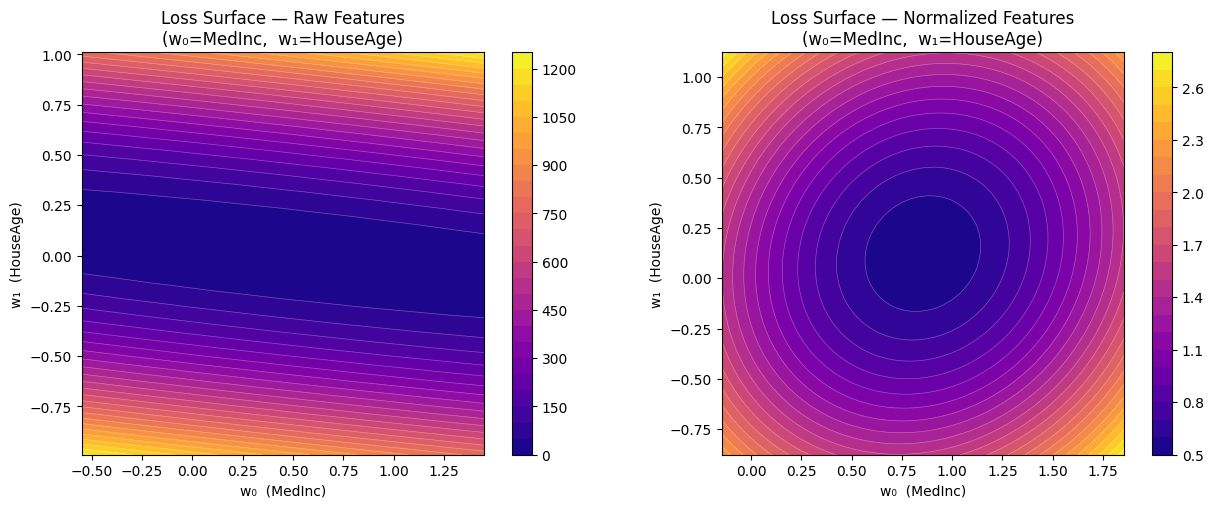

In [8]:
# Bonus Part B — Loss Surface Geometry
# We vary w_0 (MedInc weight) and w_1 (HouseAge weight) and fix all others at the optimum.
feat_i, feat_j = 0, 1
grid_size = 50
feature_names = list(housing.feature_names)

# Closed-form solution on RAW features (needed for the raw-feature plot)
X_raw_local = torch.tensor(X_train_np, dtype=torch.float32)
X_raw_aug   = torch.cat([X_raw_local, torch.ones(X_raw_local.shape[0], 1)], dim=1)
W_star_raw  = torch.linalg.solve(X_raw_aug.T @ X_raw_aug, X_raw_aug.T @ y_train)

def compute_loss_grid_2d(X_aug, y, W_opt, fi, fj, delta):
    """Evaluate MSE on a grid of (w_fi, w_fj); all other weights fixed at W_opt."""
    W_fixed  = W_opt.detach().squeeze().clone()
    wi_range = torch.linspace(W_fixed[fi] - delta, W_fixed[fi] + delta, grid_size)
    wj_range = torch.linspace(W_fixed[fj] - delta, W_fixed[fj] + delta, grid_size)
    loss_g   = torch.zeros(grid_size, grid_size)
    for i, wi in enumerate(wi_range):
        for j, wj in enumerate(wj_range):
            W_tmp      = W_fixed.clone()
            W_tmp[fi]  = wi
            W_tmp[fj]  = wj
            y_pred     = X_aug @ W_tmp.unsqueeze(1)
            loss_g[i, j] = ((y_pred - y) ** 2).mean()
    return loss_g, wi_range, wj_range

# Choose delta so the plot covers ~the same "loss increase" in each direction
# H_ii = 2 * (X^T X)_{ii} / N  →  delta = sqrt(N / (2 * (X^T X)_{ii}))  (unit loss increase)
N_tr = X_train.shape[0]

def hessian_delta(XtX, idx):
    return float((N_tr / (2.0 * XtX[idx, idx].item())) ** 0.5)

# Use uniform delta = max(delta_i, delta_j) so both axes span the same range
# → shape difference (elongated vs circular) is directly visible
XtX_raw_aug  = X_raw_aug.T    @ X_raw_aug
XtX_norm_aug = X_train_aug.T  @ X_train_aug

delta_raw  = max(hessian_delta(XtX_raw_aug,  feat_i), hessian_delta(XtX_raw_aug,  feat_j))
delta_norm = max(hessian_delta(XtX_norm_aug, feat_i), hessian_delta(XtX_norm_aug, feat_j))
delta = 1.0

loss_raw,  wi_raw,  wj_raw  = compute_loss_grid_2d(X_raw_aug,   y_train, W_star_raw, feat_i, feat_j, delta)
loss_norm, wi_norm, wj_norm = compute_loss_grid_2d(X_train_aug, y_train, W_star,     feat_i, feat_j, delta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, loss_g, wi, wj, title in [
    (axes[0], loss_raw,  wi_raw,  wj_raw,  'Raw Features'),
    (axes[1], loss_norm, wi_norm, wj_norm, 'Normalized Features'),
]:
    W0g, W1g = torch.meshgrid(wi, wj, indexing='ij')
    cp = ax.contourf(W0g.numpy(), W1g.numpy(), loss_g.numpy(), levels=25, cmap='plasma')
    ax.contour(W0g.numpy(), W1g.numpy(), loss_g.numpy(), levels=25,
               colors='white', alpha=0.3, linewidths=0.5)
    plt.colorbar(cp, ax=ax)
    ax.set_title(f'Loss Surface — {title}\n(w₀={feature_names[feat_i]},  w₁={feature_names[feat_j]})')
    ax.set_xlabel(f'w₀  ({feature_names[feat_i]})');  ax.set_ylabel(f'w₁  ({feature_names[feat_j]})')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


### Bonus Part B — Analysis

**What is the shape of the contours without normalization?**

Without normalization, features span very different scales (e.g., `MedInc` ≈ 0–15 vs `HouseAge` ≈ 2–52). This causes the Hessian diagonal entries $H_{ii} = \frac{2}{N}\|x_i\|^2$ to differ substantially across feature directions, resulting in **elongated (eccentric) elliptical contours** in the $(w_0, w_1)$ plane.

**What is the shape after normalization?**

After normalization all features have similar variance, so the Hessian diagonal entries are approximately equal: $H_{ii} \approx \frac{2}{N} \cdot N = 2$ for each feature. The contours become **much more circular** (isotropic).

**Are they circular or elongated?**

- **Without normalization**: Elongated / eccentric ellipses, possibly tilted due to feature correlations.  
- **After normalization**: Near-circular ellipses.

**How does this relate to the condition number?**

The condition number $\kappa = \lambda_{\max} / \lambda_{\min}$ directly measures the eccentricity of the contour ellipses:

- $\kappa \approx 1$: circular contours → gradient points almost directly toward the minimum → fast convergence.  
- $\kappa \gg 1$: highly elongated contours → gradient is nearly perpendicular to the line toward the minimum → gradient descent zigzags slowly.

Normalization dramatically reduces $\kappa$, transforming a narrow ravine into a bowl and making optimization far more tractable.



# Task 3 — Optimization Study (2 pts)

Run controlled experiments to study optimization behavior.

### Requirements

Train the same model while changing only the **learning rate**.

Test at least 3 learning rates:

* **too small** (slow learning)
* **reasonable**
* **too large** (divergence or oscillations)

For each learning rate:

* plot training loss curve,
* report final train/val MSE.

Additionally, track and plot the gradient norm per epoch:

$$
\left \| \nabla_W L \right\|_2
$$

### Required Explanation (Markdown)

* What does divergence look like in the loss curve?
* Explain why too-large learning rate causes instability.
* How does **normalization** affect the range of “reasonable” learning rates?


---

# ✅ Deliverables Checklist

Your notebook must contain:

* dataset preparation + split,
* normalization step,
* model implementation (forward + MSE),
* training loop with manual updates,
* plots (loss curves, gradient norm),
* closed-form solution comparison,
* written answers to required questions.

In [9]:
# Task 3 — Optimization Study: effect of learning rate
learning_rates_study = {'Too Small': 0.001, 'Reasonable': 0.1, 'Too Large *': 0.482, 'Too Large': 0.5}
n_epochs_study = 300

results_lr = {}

for label, lr_val in learning_rates_study.items():
    torch.manual_seed(42)
    W_lr = torch.randn(d, 1, requires_grad=True)
    b_lr = torch.randn(1,    requires_grad=True)

    t_losses, v_losses, grad_norms = [], [], []

    for epoch in range(n_epochs_study):
        y_pred = X_train @ W_lr + b_lr
        loss   = ((y_pred - y_train) ** 2).mean()

        t_losses.append(loss.item())

        # Stop early on divergence
        if not torch.isfinite(loss):
            print(f"  [{label}] Loss diverged at epoch {epoch + 1}")
            break

        loss.backward()
        grad_norms.append(W_lr.grad.norm().item())

        with torch.no_grad():
            W_lr -= lr_val * W_lr.grad
            b_lr -= lr_val * b_lr.grad
            W_lr.grad.zero_()
            b_lr.grad.zero_()

        with torch.no_grad():
            y_pred_v = X_val @ W_lr + b_lr
            loss_v   = ((y_pred_v - y_val) ** 2).mean()
        v_losses.append(loss_v.item())

    # Final MSE (may be NaN if diverged)
    with torch.no_grad():
        final_train = ((X_train @ W_lr + b_lr - y_train) ** 2).mean().item()
        final_val   = ((X_val   @ W_lr + b_lr - y_val)   ** 2).mean().item()

    results_lr[label] = {
        'lr': lr_val,
        'train_losses': t_losses,
        'val_losses':   v_losses,
        'grad_norms':   grad_norms,
        'final_train_mse': final_train,
        'final_val_mse':   final_val,
    }
    print(f"LR = {lr_val:.3f}  ({label:10s}): Final Train MSE = {final_train:.4f},  Val MSE = {final_val:.4f}")


LR = 0.001  (Too Small ): Final Train MSE = 2.8682,  Val MSE = 2.9084
LR = 0.100  (Reasonable): Final Train MSE = 0.5183,  Val MSE = 0.5579
LR = 0.482  (Too Large *): Final Train MSE = 0.5179,  Val MSE = 0.5559
LR = 0.500  (Too Large ): Final Train MSE = 22723404.0000,  Val MSE = 27953076.0000


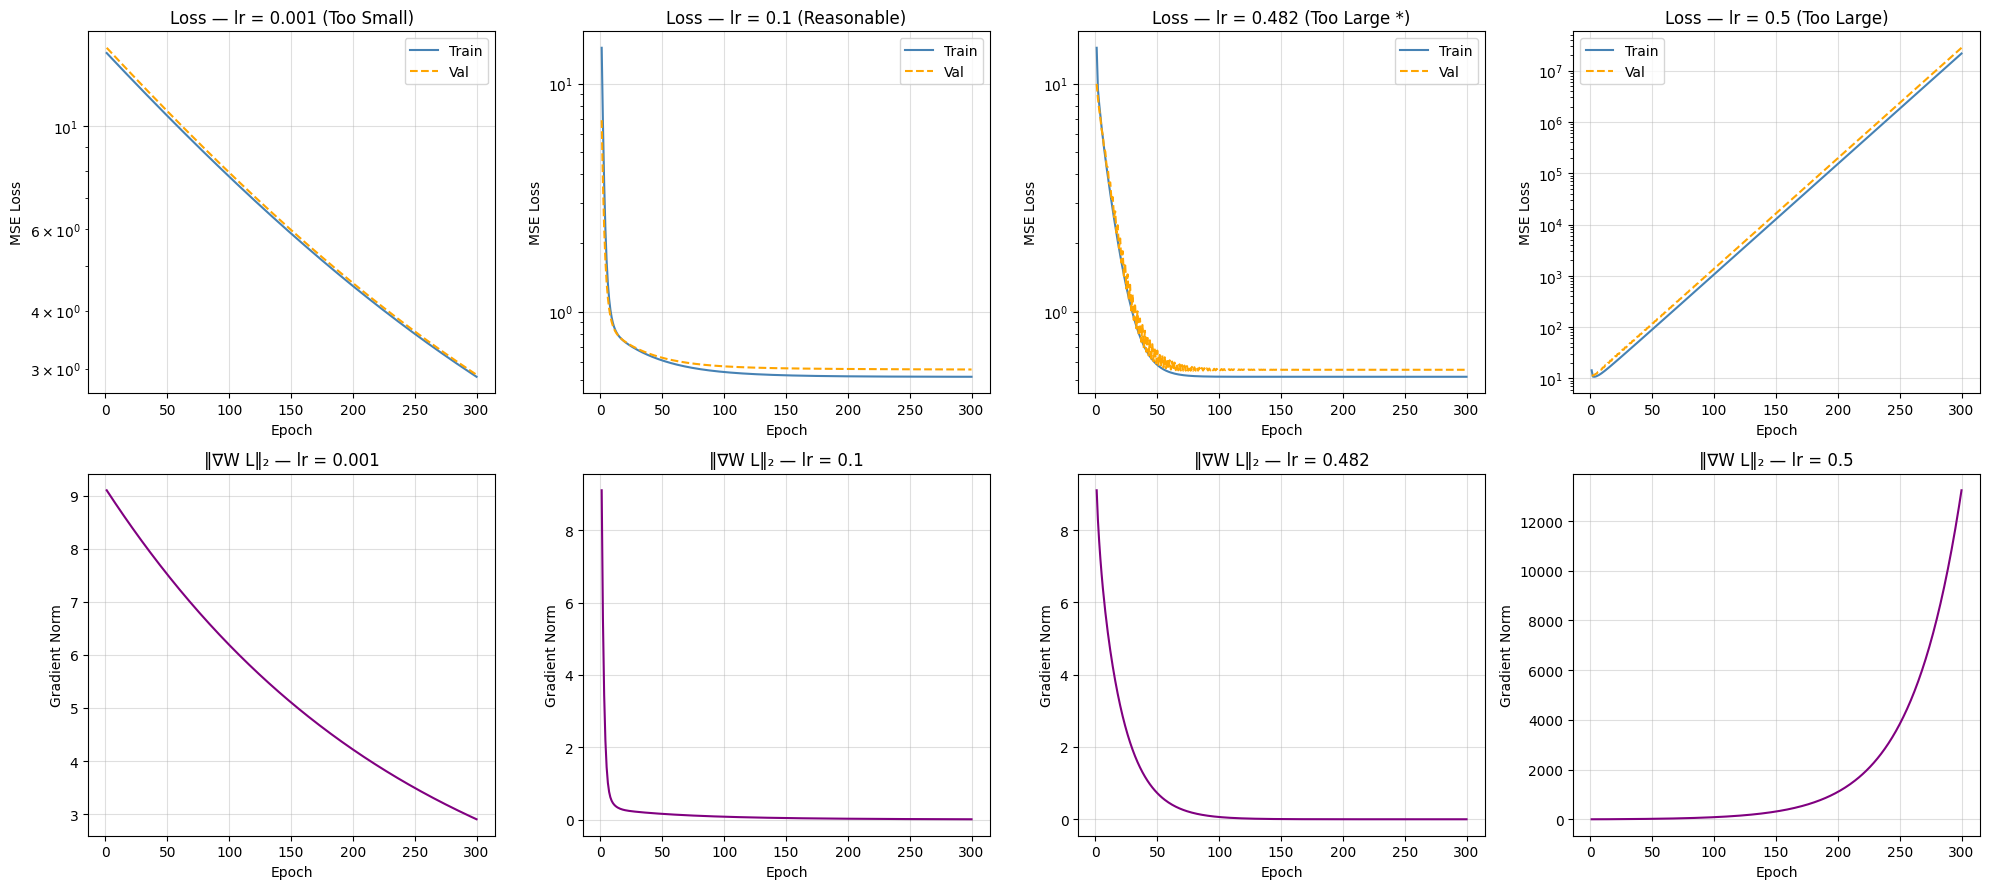


Label               LR   Final Train MSE   Final Val MSE
----------------------------------------------------------
Too Small        0.001            2.8682          2.9084
Reasonable       0.100            0.5183          0.5579
Too Large *      0.482            0.5179          0.5559
Too Large        0.500     22723404.0000   27953076.0000


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col, (label, res) in enumerate(results_lr.items()):
    # ── top row: loss curves ──────────────────────────────────────────────
    t_ep = range(1, len(res['train_losses']) + 1)
    v_ep = range(1, len(res['val_losses'])   + 1)
    axes[0, col].plot(t_ep, res['train_losses'], label='Train', color='steelblue', linewidth=1.5)
    axes[0, col].plot(v_ep, res['val_losses'],   label='Val',   color='orange',    linewidth=1.5, linestyle='--')
    axes[0, col].set_title(f"Loss — lr = {res['lr']} ({label})")
    axes[0, col].set_xlabel('Epoch');  axes[0, col].set_ylabel('MSE Loss')
    axes[0, col].set_yscale('log');    axes[0, col].legend();  axes[0, col].grid(True, alpha=0.4)

    # ── bottom row: gradient norms ────────────────────────────────────────
    gn = res['grad_norms']
    axes[1, col].plot(range(1, len(gn) + 1), gn, color='purple', linewidth=1.5)
    axes[1, col].set_title(f"‖∇W L‖₂ — lr = {res['lr']}")
    axes[1, col].set_xlabel('Epoch');  axes[1, col].set_ylabel('Gradient Norm')
    axes[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Label':<15} {'LR':>6}  {'Final Train MSE':>16}  {'Final Val MSE':>14}")
print("-" * 58)
for label, res in results_lr.items():
    print(f"{label:<15} {res['lr']:>6.3f}  {res['final_train_mse']:>16.4f}  {res['final_val_mse']:>14.4f}")


### Task 3 — Explanations

**What does divergence look like in the loss curve?**

Divergence appears as an explosive, monotonically increasing loss — after a few initial steps the loss rockets to `inf` or `NaN` instead of decreasing. Each gradient update overshoots the minimum so severely that the parameters are pushed further from the optimum, compounding the error geometrically every epoch.

---

**Explain why a too-large learning rate causes instability.**

In the eigen-decomposition of the Hessian $H = V \Lambda V^T$, the gradient descent update in eigen-direction $k$ satisfies:

$$w_t^{(k)} = (1 - \eta \lambda_k)^t \, w_0^{(k)}$$

Convergence requires $|1 - \eta \lambda_k| < 1$, i.e., $\eta < 2 / \lambda_{\max}$.

If $\eta > 2/\lambda_{\max}$: the factor $(1 - \eta \lambda_k)$ becomes $< -1$ for the largest eigenvalue direction, so that component **oscillates with growing amplitude** every iteration → the loss diverges.

---

**How does normalization affect the range of "reasonable" learning rates?**

Without normalization, $\lambda_{\max}(X^TX/N)$ can be extremely large (features with large variance dominate). The stability threshold $2/\lambda_{\max}$ becomes very small, forcing the learning rate to be tiny — which also means painfully slow convergence.

After z-score normalization all features have unit variance, so the eigenvalues of $X^TX/N$ are bounded in a moderate range (roughly $[0, d]$ for $d$ features). This pushes the stability threshold $2/\lambda_{\max}$ to an $O(1/d)$ level where learning rates like $0.05$–$0.3$ work well. Normalization effectively **widens the safe interval of learning rates**, making hyperparameter tuning much easier.
